In [ ]:
%load_ext autoreload
%autoreload 2

In [33]:
import random

import numpy as np
from matplotlib import pyplot as plt

from platform_stabilization.systems import DefaultSystem
from platform_stabilization.chi_functions import ChiFunctionFactory
from platform_stabilization.constants import g

In [34]:
random.seed(1234)

In [ ]:
M_upper = 1.1
F_upper = 20
J_upper = 1.1
L_lower = 0.9
omega_upper = 0.1
eta = 0.5
alpha_max = np.pi / 4
theta_max = np.pi / 5

In [37]:
theta_big = np.cos(theta_max + alpha_max) / np.cos(theta_max - alpha_max)
theta_big

np.float64(0.15838444032453633)

In [38]:
system = DefaultSystem(
    M = 1,
    J = 1,
    L1 = 0.5,
    L2 = 0.5,
    alpha_1 = 0.6,
    alpha_2 = 0.6,
)

In [39]:
chi_function = ChiFunctionFactory.construct("tanh")

In [64]:
F_0_lower = M_upper * g / 2
F_0_upper = F_upper * (1 + eta * theta_big) / 2
print(F_0_lower, F_0_upper)

# F_0 = random.uniform(F_0_lower, F_0_upper)
F_0 = 10.610891316845795
print(F_0)

F_theta_lower = F_0 * ((1 - eta * theta_big) / (1 + eta * theta_big))
F_theta_upper = min(F_upper - F_0, F_0)
print(F_theta_lower, F_theta_upper)

# F_theta = random.uniform(F_theta_lower, F_theta_upper)
F_theta = 9.201478211943186
print(F_theta)

cos_therm = np.cos(theta_max + alpha_max) ** 2

mu_lower = 0
mu_upper = min(
    omega_upper / chi_function.chi_upper,
    np.sqrt(
        (F_theta - F_0 * ((1 - eta * theta_big) / (1 + eta * theta_big))) * \
        ((L_lower * cos_therm) / (J_upper * chi_function.chi_upper * chi_function.chi_dot_upper))
    ),
)
print(mu_lower, mu_upper)

# mu = random.uniform(mu_lower, mu_upper)
mu = mu_upper * 0.9
print(mu)


5.395500000000001 10.79192220162268
10.610891316845795
9.05361537363115 9.389108683154205
9.201478211943186
0 0.05441102067399815
0.04896991860659834


In [65]:
theta_0 = 0.27201965947101825

t_max = 1000

In [66]:
y_0 = (
    theta_0,
    0,
    1,
    0,
)
t_span = (0, t_max)

In [67]:
t, y = system.simulate(
    F_0=F_0,
    F_theta=F_theta,
    mu=mu,
    chi_function=chi_function,
    y_0=y_0,
    t_span=t_span,
    rtol=1e-4,
    atol=1e-4,
    method="RK23"
)

In [68]:
t.shape

(4318873,)

In [69]:
y.shape

(4, 4318873)

In [70]:
y[0, :][-1]

np.float64(0.003177801205870191)

In [71]:
np.argmax(y[0, :] < 0.01)

np.int64(252510)

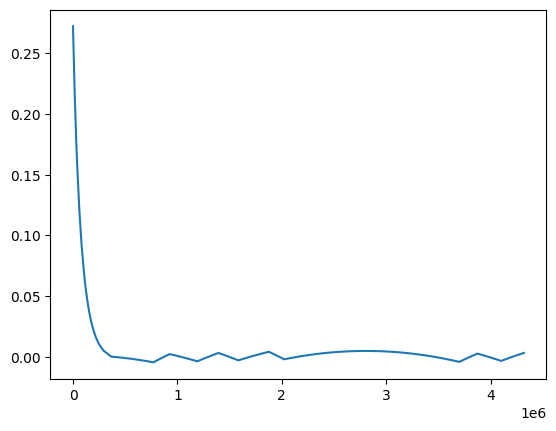

In [72]:
plt.plot(y[0, :])

In [81]:
(180 / np.pi) * y[0, -1]

np.float64(0.1466880279320405)

In [97]:
np.pi/5 * (1 - 0.05), np.pi/5 * (1 + 0.05)

(0.5969026041820606, 0.6597344572538566)

In [96]:
np.pi/6 * (1 - 0.05), np.pi/6 * (1 + 0.05)

(0.49741883681838384, 0.5497787143782138)

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
data_dir = "/home/jovyan/people/makarov/platform-stabilization/experiments3/0"

In [3]:
from glob import glob
import json

In [4]:
iterations = glob(f"{data_dir}/**")
print(len(iterations))

1000


 99%|█████████▉| 988/1000 [00:25<00:00, 33.98it/s]

/home/jovyan/people/makarov/platform-stabilization/experiments3/0/983
0.05584931394640239
-----------------------------------


100%|██████████| 1000/1000 [00:26<00:00, 38.40it/s]


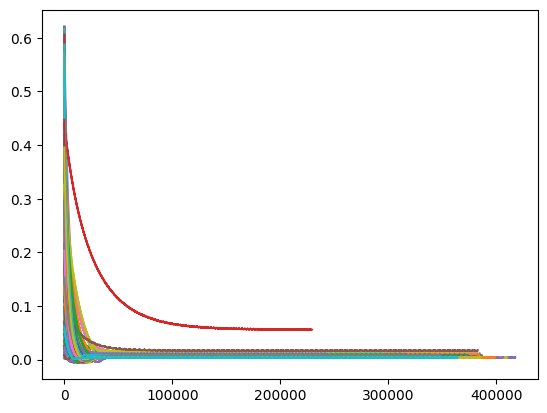

In [41]:
for iteration in tqdm(iterations):
    y = np.load(f"{iteration}/y.npy")
    if y[0, -1] > 0.05:
        print(iteration)
        print(y[0, -1])
        print('-----------------------------------')

    plt.plot(y[0])
plt.show()

In [28]:
t.shape

(213481,)

0.05584931394640239


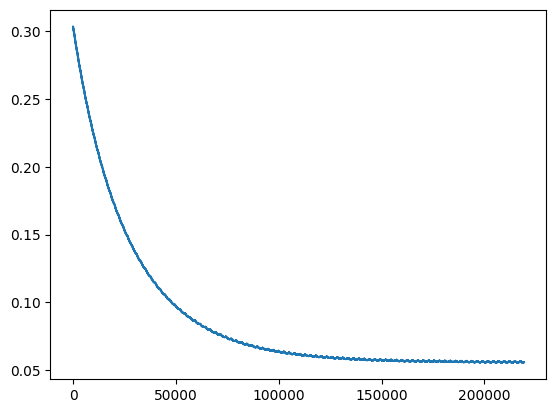

In [43]:
y = np.load(f"/home/jovyan/people/makarov/platform-stabilization/experiments3/0/983/y.npy")
t = np.load(f"/home/jovyan/people/makarov/platform-stabilization/experiments3/0/983/t.npy")

print(y[0, -1])
plt.plot(y[0, 10000:])

In [30]:
end_index = np.argmax(y < 0.05)
print(end_index)

time_used = t[end_index]
print(time_used)

3693
18.309724086309448


0.003739880511141937
0.003529879097430396
0.0034901551130062467
0.004097624369060378
0.004188101898727122
0.004037467510337711
0.003829376428799775
0.003997787039595905
0.00449009620915125


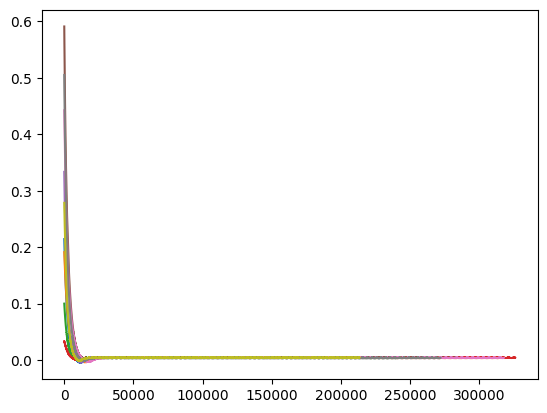

In [25]:

for i in range(1, 10):
	y = np.load(f"/home/jovyan/people/makarov/platform-stabilization/experiments3/1/{i}/y.npy")
	t = np.load(f"/home/jovyan/people/makarov/platform-stabilization/experiments3/1/{i}/t.npy")

	print(y[0, -1])
	plt.plot(y[0, :])
plt.show()

In [26]:
a = "/home/jovyan/people/makarov/platform-stabilization/experiments/0/simulation_results/5326"

y = np.load(f"{a}/y.npy")

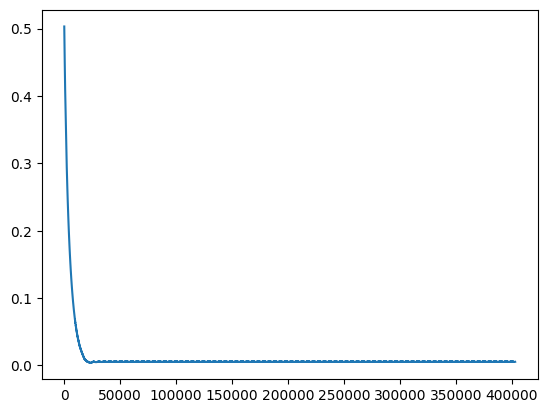

In [27]:
plt.plot(y[0, :])

0.008136300787047364
0.004566936188657602
0.0040425976212000005
0.007760805424299239
0.005198213106412378
0.007449680623425784
0.0035285502750595312
0.005743280669171733
0.004624993721281582
0.004430087454635541


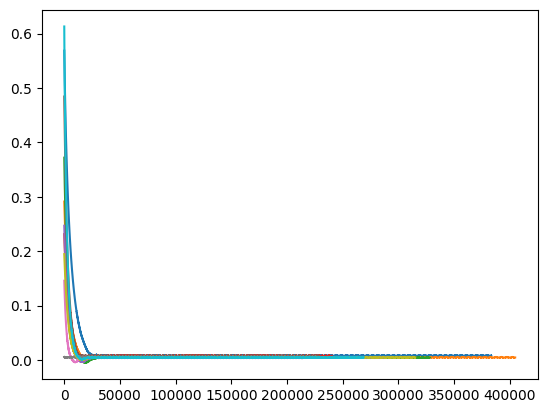

In [81]:
for i in range(10):
    print(data[i]["y"][0][-1])
    plt.plot(data[i]["y"][0])
plt.show()

In [1]:
import json
import os
from glob import glob

import numpy as np
from tqdm.notebook import tqdm

In [2]:
def check_conditions_1(
    theta_values,
    threshold: float,
) -> bool:
    return theta_values[-1] < threshold

def check_conditions_2(
    theta_values,
    theta_upper: float,
) -> bool:
    return np.max(np.abs(theta_values)) < theta_upper

def check_conditions_3(
    theta_dot_values,
    omega_upper: float,
) -> bool:
    return np.max(np.abs(theta_dot_values)) < omega_upper

def check_conditions_4(
    c_dot_values,
) -> bool:
    return np.min(c_dot_values[1:]) > 0

In [3]:
def construct_bootstrap_interval(
    values,
    n_bootstrap_samples: int,
    condidence_level: float,
):
    estimators = []

    for _ in range(n_bootstrap_samples):
        current_bootstrap_sample = np.random.choice(
            values,
            size=len(values),
            replace=True,
        )

        estimators.append(np.mean(current_bootstrap_sample))

    left_border, right_border = np.quantile(
        estimators,
        q=[(1 - condidence_level) / 2, (1 + condidence_level) / 2]
    )
    
    return (
        round(float(left_border), 2),
        round(float(right_border), 2)
    )


In [4]:
data_dir = "/home/jovyan/people/makarov/platform-stabilization/experiments/3"

In [5]:
threshold = 0.05
confidence_level = 0.95

In [6]:
for setup_dir in glob(os.path.join(data_dir, "**")):
    print(setup_dir)

    with open(os.path.join(setup_dir, "0", "used_config.json")) as f:
        config = json.load(f)
        
    print(config["params"])

    omage_upper = config["estimates"]["omega_upper"]
    theta_upper = config["estimates"]["theta_max"]

    cond_1 = cond_2 = cond_3 = cond_4 = 0
    terminal_timings = []
    
    n_trials = 0

    for experiment_dir in tqdm(glob(os.path.join(setup_dir, "**"))):
        n_trials += 1

        y = np.load(os.path.join(experiment_dir, "y.npy"))
        t = np.load(os.path.join(experiment_dir, "t.npy"))
        
        cond_1_flag = check_conditions_1(
            y[0],
            threshold,
        )
        cond_1 += cond_1_flag

        cond_2 += check_conditions_2(
            y[0],
            theta_upper,
        )

        cond_3 += check_conditions_3(
            y[1],
            omage_upper,
        )

        cond_4 += check_conditions_4(
            y[3]
        )

        if cond_1_flag:
            terminal_index = np.argmax(y[0, :] < threshold)
            terminal_timings.append(t[terminal_index])

    print(round(cond_1/n_trials, 3))
    print(round(cond_2/n_trials, 3))
    print(round(cond_3/n_trials, 3))
    print(round(cond_4/n_trials, 3))
    print(
        construct_bootstrap_interval(
            terminal_timings, 
            n_trials, 
            confidence_level,
        )
    )

    print("-----------------------")


/home/jovyan/people/makarov/platform-stabilization/experiments/3/0
{'M': 1, 'J': 1, 'L1': 0.5, 'L2': 0.5, 'alpha_1': 0.6, 'alpha_2': 0.7}


  0%|          | 0/1000 [00:00<?, ?it/s]

1.0
1.0
1.0
1.0
(17.96, 19.79)
-----------------------
/home/jovyan/people/makarov/platform-stabilization/experiments/3/1
{'M': 1, 'J': 1, 'L1': 0.5, 'L2': 0.5, 'alpha_1': 0.6, 'alpha_2': 0.6}


  0%|          | 0/1000 [00:00<?, ?it/s]

1.0
1.0
1.0
1.0
(17.13, 19.03)
-----------------------
/home/jovyan/people/makarov/platform-stabilization/experiments/3/2
{'M': 1, 'J': 1, 'L1': 0.5, 'L2': 0.5, 'alpha_1': 0.6, 'alpha_2': 0.5}


...

0.974
1.0
1.0
1.0
(21.49, 22.93)
-----------------------
/home/jovyan/people/makarov/platform-stabilization/experiments/3/5
{'M': 1, 'J': 1, 'L1': 0.5, 'L2': 0.5, 'alpha_1': 0.6, 'alpha_2': 0.2}


  0%|          | 0/1000 [00:00<?, ?it/s]

0.928
1.0
1.0
1.0
(29.71, 31.42)
-----------------------
/home/jovyan/people/makarov/platform-stabilization/experiments/3/6
{'M': 1, 'J': 1, 'L1': 0.5, 'L2': 0.5, 'alpha_1': 0.6, 'alpha_2': 0.1}


  0%|          | 0/1000 [00:00<?, ?it/s]

0.948
1.0
1.0
1.0
(27.01, 28.55)
-----------------------
